In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import time

from models.custom_cnn import BaselineCNN

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
data_dir = '../dataSet/archive/seg_train/seg_train'
test_dir = '../dataSet/archive/seg_test/seg_test'

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_train = datasets.ImageFolder(data_dir, transform=transform)

train_size = int(0.8 * len(full_train))
val_size = len(full_train) - train_size
train_dataset, val_dataset = random_split(full_train, [train_size, val_size])

test_dataset = datasets.ImageFolder(test_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')
print(f'Classes: {full_train.classes}')

Train: 11227, Val: 2807, Test: 3000
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [4]:
model = BaselineCNN(num_classes=6).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')


Total parameters: 8,781,574


In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [13]:
train_loader

In [6]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [7]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [8]:
num_epochs = 30
early_stopping = EarlyStopping(patience=5)

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0

Path('../checkpoints').mkdir(exist_ok=True)

print('Starting training...\n')
start_time = time.time()

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}')
    print(f'  Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '../checkpoints/baseline_best.pth')
        print(f'  ✓ Saved best model (val_acc: {val_acc:.4f})')

    early_stopping(val_loss)
    if early_stopping.early_stop:
        print(f'\nEarly stopping triggered at epoch {epoch+1}')
        break

    print()

total_time = time.time() - start_time
print(f'Training completed in {total_time/60:.2f} minutes')
print(f'Best validation accuracy: {best_val_acc:.4f}')

Starting training...

Epoch [1/30]
  Train Loss: 1.3313, Train Acc: 0.5813
  Val Loss:   0.8750, Val Acc:   0.6587
  ✓ Saved best model (val_acc: 0.6587)

Epoch [2/30]
  Train Loss: 0.8536, Train Acc: 0.6825
  Val Loss:   0.7530, Val Acc:   0.7157
  ✓ Saved best model (val_acc: 0.7157)

Epoch [3/30]
  Train Loss: 0.7453, Train Acc: 0.7367
  Val Loss:   0.7514, Val Acc:   0.7424
  ✓ Saved best model (val_acc: 0.7424)

Epoch [4/30]
  Train Loss: 0.6681, Train Acc: 0.7617
  Val Loss:   0.6541, Val Acc:   0.7652
  ✓ Saved best model (val_acc: 0.7652)

Epoch [5/30]
  Train Loss: 0.6394, Train Acc: 0.7795
  Val Loss:   0.5395, Val Acc:   0.7937
  ✓ Saved best model (val_acc: 0.7937)

Epoch [6/30]
  Train Loss: 0.5900, Train Acc: 0.7898
  Val Loss:   0.4804, Val Acc:   0.8322
  ✓ Saved best model (val_acc: 0.8322)

Epoch [7/30]
  Train Loss: 0.5699, Train Acc: 0.8014
  Val Loss:   0.4601, Val Acc:   0.8365
  ✓ Saved best model (val_acc: 0.8365)

Epoch [8/30]
  Train Loss: 0.5158, Train Acc: 0

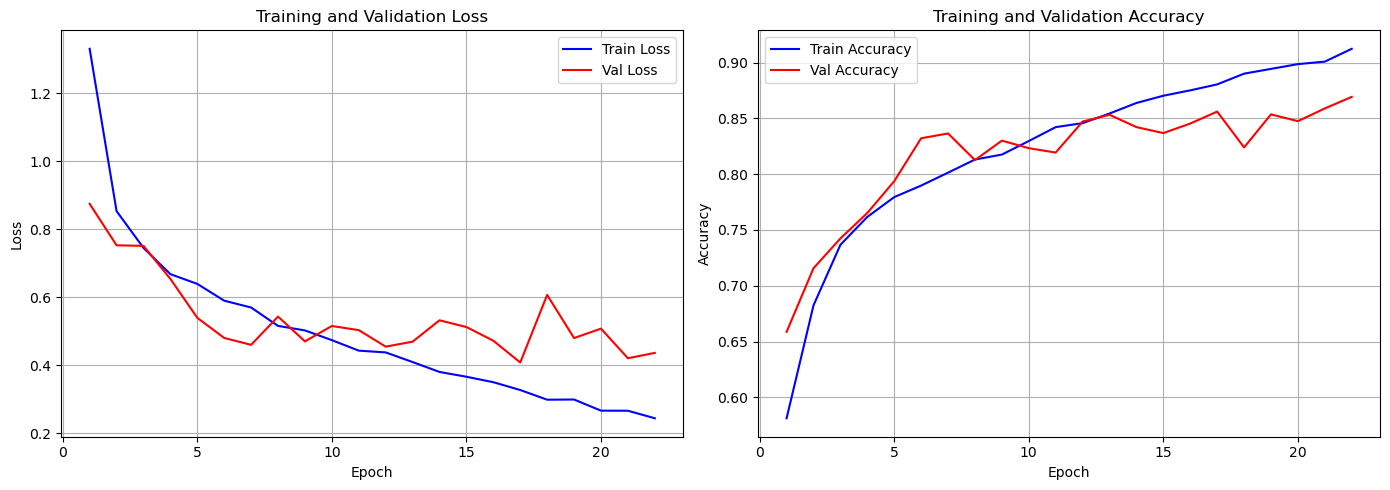

Final train accuracy: 0.9124
Final val accuracy:   0.8693
Overfitting gap:      0.0431


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

ax1.plot(epochs_range, history['train_loss'], 'b-', label='Train Loss')
ax1.plot(epochs_range, history['val_loss'], 'r-', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, history['train_acc'], 'b-', label='Train Accuracy')
ax2.plot(epochs_range, history['val_acc'], 'r-', label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
Path('../results').mkdir(exist_ok=True)
plt.savefig('../results/baseline_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Final train accuracy: {history["train_acc"][-1]:.4f}')
print(f'Final val accuracy:   {history["val_acc"][-1]:.4f}')
print(f'Overfitting gap:      {history["train_acc"][-1] - history["val_acc"][-1]:.4f}')

In [14]:
model.load_state_dict(torch.load('../checkpoints/baseline_best.pth', weights_only=True))

test_loss, test_acc = validate(model, test_loader, criterion, device)

print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

Test Loss: 0.4578
Test Accuracy: 0.8660
